In [1]:
import numpy as np #handling array objects
import os #doing the file seeking to find the right location in the file
import matplotlib.pyplot as plt #plotting
from scipy.optimize import curve_fit
import tqdm
import scipy

In [28]:
def readInOutputFile(outputFilename):
    optionsStructType = np.dtype([
        ('B0', np.float64, 3),
        ('E', np.float64, 3),
        ('L', np.float64, 3),
        ('yi', np.float64, 3),
        ('posHistBins', np.float64, 3),
        ('m', np.float64),
        ('t0', np.float64),
        ('tf', np.float64),
        ('rtol', np.float64),
        ('atol', np.float64),
        ('beta', np.float64),
        ('uround', np.float64),
        ('safe', np.float64),
        ('fac1', np.float64),
        ('fac2', np.float64),
        ('hmax', np.float64),
        ('hmin', np.float64),
        ('h', np.float64),
        ('T', np.float64),
        ('gamma', np.float64),
        ('V', np.float64),
        ('a', np.float64),
        ('w', np.float64),
        ('swapStepSize', np.float64),
        ('ioutInt', np.float64),
        ('nmax', np.uint32),
        ('seed', np.uint32),
        ('integratorType', np.int32),
        ('numParticles', np.int32),
        ('numPerGPUBlock', np.int32),
        ('iout', np.int32),
        ('numPhiBins', np.int32),
        ('numThetaBins', np.int32),
        ('dist', 'S', 1),
        ('output', 'S', 1),
        ('gas_coll', bool),
        ('diffuse', bool),
        ('gravity', bool),
        ('fixedStepSize', bool),
        ('keepStepSize', bool),
        ('pad', 'S', 1) #this is padding space just designed to fix the structure padding done in C++
    ])
    file = open(outputFilename, 'rb')
    parameters = np.fromfile(file, count=1, dtype=optionsStructType)[0]
    data = None
    if parameters['output'] == b'n':
        #in this case it was the full dump of all particle data
        outputDtype = np.dtype([
            ('t', '<f8'),
            ('xx', '<f8'),
            ('xy', '<f8'),
            ('xz', '<f8'),
            ('vx', '<f8'),
            ('vy', '<f8'),
            ('vz', '<f8'),
            ('sx', '<f8'),
            ('sy', '<f8'),
            ('sz', '<f8')])
        file.seek(0, 0)
        data = np.fromfile(file, dtype=outputDtype, offset=parameters.nbytes)
        numTimes = data.shape[0]//parameters['numParticles']
        numPer = int((parameters['tf']-parameters['t0'])/parameters['ioutInt'])+1
        data = data[:numTimes*parameters['numParticles']].reshape(-1, parameters['numParticles']).T #this returns the data in a little more convenient format, I think
    elif parameters['output'] == b'h':
        #this is the histogram output format instead now
        numx = int(parameters['L'][0]/parameters['gridSize'])+1
        numy = int(parameters['L'][1]/parameters['gridSize'])+1
        numz = int(parameters['L'][2]/parameters['gridSize'])+1

        numVecBins = int(np.ceil(2.0/parameters['vecBinSize']))

        xbins = np.arange(-parameters['L'][0]/2.0, parameters['L'][0]/2.0, parameters['gridSize'])
        ybins = np.arange(-parameters['L'][0]/2.0, parameters['L'][0]/2.0, parameters['gridSize']) 
        zbins = np.arange(-parameters['L'][0]/2.0, parameters['L'][0]/2.0, parameters['gridSize'])
        sbins = np.arange(-1.0, 1.0, parameters['vecBinSize'])
        outputDtype = np.dtype([
            ('t', np.float64),
            ('x', np.uint32, numx),
            ('y', np.uint32, numy),
            ('z', np.uint32, numz),
            ('sx', np.uint32, numVecBins),
            ('sy', np.uint32, numVecBins),
            ('sz', np.uint32, numVecBins)
        ])
        file.seek(0, 0)
        data = np.fromfile(file, dtype=outputDtype, offset=parameters.nbytes)
        data = {'xbins': xbins,
               'ybins': ybins,
               'zbins': zbins,
               'sbins': sbins,
               'data': data}
    elif parameters['output'] == b'a':
        outputDtype = np.dtype([
            ('t', np.float64),
            ('sx', np.float64),
            ('dsx', np.float64),
            ('sy', np.float64),
            ('dsy', np.float64),
            ('sz', np.float64),
            ('dsz', np.float64)
        ])
        file.seek(0, 0)
        data = np.fromfile(file, dtype=outputDtype, offset=parameters.nbytes)
    file.close()
    return parameters, data

def shiftDatapoints(phis):
    shifted = np.copy(phis)
    initHist, bins = np.histogram(phis, bins = 1000) #calculate the initial histogram and then adjust based on the mode
    peakloc = np.argmax(initHist)
    location = bins[peakloc]
    #shift everything to be close to that peak
    lowLocs = shifted<=(location-np.pi)
    highLocs = shifted>=(location+np.pi)
    shifted[lowLocs] += 2.0*np.pi
    shifted[highLocs] -= 2.0*np.pi
    mean = np.nanmean(shifted)
    std = np.nanstd(shifted)
    shifted[shifted<(mean-std*5)] = np.nan
    shifted[shifted>(mean+std*5)] = np.nan
    return shifted

def analyzeDataset(dset, randomSample = False, plot=False, coord1 = 'sy', coord2 = 'sz'):
    times = np.sort(np.unique(dset[0]['t']))
    phis = np.arctan2(dset[coord1], dset[coord2])
    for i in range(len(times)):
        if randomSample:
            phis[:,i] = shiftDatapoints(np.random.choice(phis[:,i], size=phis[:,i].shape))
        else:
            phis[:,i] = shiftDatapoints(phis[:,i])
        if plot:
            plt.hist(phis[:,i], bins = 1000)
            plt.title(times[i])
            plt.yscale('log')
            plt.show()
    means = np.nanmean(phis, axis=0)
    stds = np.nanstd(phis, axis=0)
    means = np.abs(means)
    return times, means, stds

def writeParameterFile(filename, runParameters):
    with open(filename, 'w') as f:
        for key in runParameters:
            if key == 'particle':
                if runParameters['particle'] == 'neutron':
                    gamma = '-1.832471850e8'
                    m = '1.674927e-27'
                    f.write('gamma, '+gamma + '\n')
                    f.write('m, '+m + '\n')
                elif runParameters['particle'] == 'helium-3':
                    gamma = '-2.037947093e8'
                    m = '1.20200437865e-26'
                    f.write('gamma, '+gamma + '\n')
                    f.write('m, '+m)
            else:
                f.write(key + ', '+runParameters[key]+'\n')
    return

In [49]:
filename = 'neutronTest.txt'
outDir = '/storage/home/hcoda1/9/dmathews33/scratch/spinDressing/initialTest/'
parameters = {}
parameters['particle'] = 'neutron'
parameters['V']='1.0'
parameters['T']='0.4'
parameters['gas_coll']='false'
parameters['diffuse']='false'
parameters['gravity']='true'
parameters['B0'] = '3.0e-6, 0, 0'
parameters['E'] = '75.0e5, 0, 0'
parameters['numParticles'] = '32'
parameters['t0']='0.0'
parameters['tf']='1.0'
parameters['ioutInt']='0.1'
parameters['a']='38.7511230e-6'
parameters['w']='6000.0'
parameters['h']='1.0e-7'
parameters['swapStepSize'] = '1.0e-9'
parameters['keepStepSize'] = 'false'
parameters['fixedStepSize'] = 'true'
parameters['dist'] = 'C'
parameters['rtol'] = '1.0e-14'
parameters['atol'] = '1.0e-14'
parameters['hmax'] = '1.0'
parameters['hmin'] = '1.0e-9'
parameters['numPerGPUBlock'] = '256'
parameters['output'] = 'n'
parameters['seed'] = '0'


parameters['integratorType']='0'
writeParameterFile(filename, parameters)
outname = outDir + 'initTestDOPCPU.out'
!~/Spin-tracking/cpuTestmain ~/Spin-tracking/scripts/neutronTest.txt {outname}
resultsDOPCPU = readInOutputFile(outname)

writeParameterFile(filename, parameters)
outname = outDir + 'initTestDOPGPU.out'
!~/Spin-tracking/gpuTestmain ~/Spin-tracking/scripts/neutronTest.txt {outname}
resultsDOPGPU = readInOutputFile(outname)

initializing
initialized
0, 0.1, 4844
1, 0.2, 4583
2, 0.3, 4568
3, 0.4, 4655
4, 0.5, 4420
5, 0.6, 4250
6, 0.7, 4590
7, 0.8, 4586
8, 0.9, 4636
9, 1, 4663
45848
0, 0.1, 70470
1, 0.2, 90771
2, 0.3, 76843
3, 0.4, 77259
4, 0.5, 85560
5, 0.6, 95808
6, 0.7, 74182
7, 0.8, 80934
8, 0.9, 74836
9, 1, 87635
814653


In [50]:
resultsDOPCPU[0]==resultsDOPGPU[0]

True

In [54]:
for name in resultsDOPCPU[1].dtype.names:
    if not np.array_equal(resultsDOPCPU[1][name], resultsDOPGPU[1][name]):
        if not np.allclose(resultsDOPCPU[1][name], resultsDOPGPU[1][name]):
            print(name)
        else:
            print(name, 'is almost perfect')
    else:
        print(name, 'is perfect')

t is perfect
xx is almost perfect
xy is almost perfect
xz is almost perfect
vx is almost perfect
vy is almost perfect
vz is almost perfect
sx is almost perfect
sy is almost perfect
sz is almost perfect


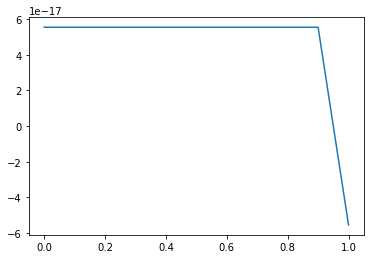

In [63]:
particle = 0
coord = 'vz'
plt.plot(resultsDOPCPU[1]['t'][0,:], resultsDOPCPU[1][coord][0,:]-resultsDOPGPU[1][coord][0,:])
plt.show()

In [24]:
parameters['integratorType']='1'
parameters['h']='1.0e-8'
writeParameterFile(filename, parameters)
outname = outDir + 'initTestRK45.out'
!~/Spin-tracking/cpuTestmain ~/Spin-tracking/scripts/neutronTest.txt {outname}
resultsRK45CPU = readInOutputFile(outname)

'''
writeParameterFile(filename, particle='neutron', V=V, T=T, gas_coll=gas_coll, diffuse=diffuse, 
                   gravity=gravity, B0=B0, E=E, numParticles=numParticles, 
                   t0=t0, tf=tf, ioutInt=ioutInt, integratorType=integratorType, 
                   a=a, w=w, keepStepSize=keepStepSize, fixedStepSize=fixedStepSize)
outname = outDir + 'initTestRK45.out'
!~/Spin-tracking/gpuTestmain ~/Spin-tracking/scripts/neutronTest.txt {outname}
resultsRK45GPU = readInOutputFile(outname)
'''

initializing
initialized
0, 0.01, 2745
1, 0.02, 1779
2, 0.03, 2154
3, 0.04, 2389
4, 0.05, 2389
5, 0.06, 2394
^C


"\nwriteParameterFile(filename, particle='neutron', V=V, T=T, gas_coll=gas_coll, diffuse=diffuse, \n                   gravity=gravity, B0=B0, E=E, numParticles=numParticles, \n                   t0=t0, tf=tf, ioutInt=ioutInt, integratorType=integratorType, \n                   a=a, w=w, keepStepSize=keepStepSize, fixedStepSize=fixedStepSize)\noutname = outDir + 'initTestRK45.out'\n!~/Spin-tracking/gpuTestmain ~/Spin-tracking/scripts/neutronTest.txt {outname}\nresultsRK45GPU = readInOutputFile(outname)\n"

In [216]:
parameters['integratorType']='2'
writeParameterFile(filename, parameters)
outname = outDir + 'initTestMagnus.out'
!~/Spin-tracking/cpuTestmain ~/Spin-tracking/scripts/neutronTest.txt {outname}
resultsMagnusCPU = readInOutputFile(outname)

'''
writeParameterFile(filename, particle='neutron', V=V, T=T, gas_coll=gas_coll, diffuse=diffuse, 
                   gravity=gravity, B0=B0, E=E, numParticles=numParticles, 
                   t0=t0, tf=tf, ioutInt=ioutInt, integratorType=integratorType, a=a, w=w)
outname = outDir + 'initTestMagnus.out'
!~/Spin-tracking/gpuTestmain ~/Spin-tracking/scripts/neutronTest.txt {outname}
resultsMagnusGPU = readInOutputFile(outname)
'''

initializing
initialized
0, 0.001, 42
1, 0.002, 31
2, 0.003, 43
3, 0.004, 43
4, 0.005, 44
5, 0.006, 37
6, 0.007, 48
7, 0.008, 43
8, 0.009, 43
9, 0.01, 43
10, 0.011, 37
11, 0.012, 42
12, 0.013, 42
13, 0.014, 36
14, 0.015, 37
15, 0.016, 37
16, 0.017, 38
17, 0.018, 37
18, 0.019, 38
19, 0.02, 37
20, 0.021, 38
21, 0.022, 38
22, 0.023, 38
23, 0.024, 38
24, 0.025, 38
25, 0.026, 38
26, 0.027, 38
27, 0.028, 38
28, 0.029, 38
29, 0.03, 38
30, 0.031, 37
31, 0.032, 38
32, 0.033, 38
33, 0.034, 38
34, 0.035, 38
35, 0.036, 38
36, 0.037, 38
37, 0.038, 38
38, 0.039, 38
39, 0.04, 38
40, 0.041, 38
41, 0.042, 38
42, 0.043, 38
43, 0.044, 38
44, 0.045, 38
45, 0.046, 38
46, 0.047, 38
47, 0.048, 38
48, 0.049, 38
49, 0.05, 38
50, 0.051, 38
51, 0.052, 38
52, 0.053, 39
53, 0.054, 39
54, 0.055, 38
55, 0.056, 38
56, 0.057, 38
57, 0.058, 38
58, 0.059, 38
59, 0.06, 38
60, 0.061, 38
61, 0.062, 38
62, 0.063, 38
63, 0.064, 38
64, 0.065, 38
65, 0.066, 37
66, 0.067, 38
67, 0.068, 38
68, 0.069, 38
69, 0.07, 38
70, 0.071, 3

556, 0.557, 32
557, 0.558, 32
558, 0.559, 32
559, 0.56, 32
560, 0.561, 32
561, 0.562, 32
562, 0.563, 32
563, 0.564, 32
564, 0.565, 32
565, 0.566, 32
566, 0.567, 32
567, 0.568, 32
568, 0.569, 32
569, 0.57, 32
570, 0.571, 32
571, 0.572, 32
572, 0.573, 32
573, 0.574, 32
574, 0.575, 32
575, 0.576, 32
576, 0.577, 32
577, 0.578, 32
578, 0.579, 32
579, 0.58, 32
580, 0.581, 32
581, 0.582, 32
582, 0.583, 32
583, 0.584, 32
584, 0.585, 32
585, 0.586, 32
586, 0.587, 32
587, 0.588, 32
588, 0.589, 32
589, 0.59, 32
590, 0.591, 32
591, 0.592, 32
592, 0.593, 32
593, 0.594, 32
594, 0.595, 32
595, 0.596, 32
596, 0.597, 32
597, 0.598, 32
598, 0.599, 32
599, 0.6, 32
600, 0.601, 32
601, 0.602, 32
602, 0.603, 32
603, 0.604, 32
604, 0.605, 32
605, 0.606, 32
606, 0.607, 32
607, 0.608, 32
608, 0.609, 32
609, 0.61, 32
610, 0.611, 32
611, 0.612, 32
612, 0.613, 32
613, 0.614, 32
614, 0.615, 32
615, 0.616, 32
616, 0.617, 32
617, 0.618, 32
618, 0.619, 32
619, 0.62, 32
620, 0.621, 32
621, 0.622, 32
622, 0.623, 32
623

"\nwriteParameterFile(filename, particle='neutron', V=V, T=T, gas_coll=gas_coll, diffuse=diffuse, \n                   gravity=gravity, B0=B0, E=E, numParticles=numParticles, \n                   t0=t0, tf=tf, ioutInt=ioutInt, integratorType=integratorType, a=a, w=w)\noutname = outDir + 'initTestMagnus.out'\n!~/Spin-tracking/gpuTestmain ~/Spin-tracking/scripts/neutronTest.txt {outname}\nresultsMagnusGPU = readInOutputFile(outname)\n"

In [223]:
for name in resultsDOPCPU[1].dtype.names:
    a = resultsDOPCPU[1][name]
    b = resultsRK45CPU[1][name]
    print(name, np.allclose(a, b))

t True
xx True
xy True
xz True
vx True
vy True
vz True
sx False
sy False
sz False


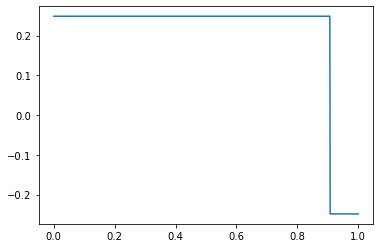

In [235]:
plt.plot(resultsDOPCPU[1]['t'][0], resultsDOPCPU[1]['vz'].mean(axis=0))

DOP: CPU and GPU Agree

RK45: CPU and GPU all agree with the original DOP CPU results

Magnus: neither CPU nor GPU agree with DOP
    CPU and GPU don't agree either
    Appears to be the NaN issue causing this
        When I mask NaN values this disappears, but they don't share the same NaN locations which is strange
    When masking NaN values it also agrees with the other methods, but we shouldn't be seeing NaN to begin with